In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('/content/daily_water_consumption.csv')
print(df.info())
print(df.head())
print(df.describe())
print(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36500 entries, 0 to 36499
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   36500 non-null  object 
 1   Person_ID              36500 non-null  object 
 2   Age                    36500 non-null  int64  
 3   Gender                 36500 non-null  object 
 4   City                   36500 non-null  object 
 5   Temperature_C          36500 non-null  float64
 6   Activity_Level         36500 non-null  object 
 7   Water_Consumed_Liters  36500 non-null  float64
dtypes: float64(2), int64(1), object(5)
memory usage: 2.2+ MB
None
         Date Person_ID  Age  Gender     City  Temperature_C Activity_Level  \
0  2025-01-01     P0001   21  Female  Karachi           22.1         Medium   
1  2025-01-02     P0001   21  Female  Karachi           41.0         Medium   
2  2025-01-03     P0001   21  Female  Karachi           26.4        

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
display(df.head())

,Date,Person_ID,Age,Gender,City,Temperature_C,Activity_Level,Water_Consumed_Liters
0,2025-01-01,P0001,21,Female,Karachi,22.1,Medium,2.40
1,2025-01-02,P0001,21,Female,Karachi,41.0,Medium,3.31
2,2025-01-03,P0001,21,Female,Karachi,26.4,High,2.96
3,2025-01-04,P0001,21,Female,Karachi,31.4,Medium,3.16
4,2025-01-05,P0001,21,Female,Karachi,35.7,Low,2.43


In [ ]:
num_days = df['Date'].nunique()
min_date = df['Date'].min()
max_date = df['Date'].max()
print(f"Number of unique days in the dataset: {num_days}")
print(f"Date range: {min_date.strftime('%Y-%m-%d')} to {max_date.strftime('%Y-%m-%d')}")

Number of unique days in the dataset: 365
Date range: 2025-01-01 to 2025-12-31


In [ ]:
avg_water_consumption = df['Water_Consumed_Liters'].mean()
print(f"Overall average water consumed per entry (person per day): {avg_water_consumption:.2f} Liters")

Overall average water consumed per entry (person per day): 2.72 Liters


In [ ]:
total_water_usage = df['Water_Consumed_Liters'].sum()
print(f"Total water consumed across all entries: {total_water_usage:.2f} Liters")

Total water consumed across all entries: 99426.07 Liters


In [ ]:
daily_total_consumption = df.groupby('Date')['Water_Consumed_Liters'].sum().reset_index()
daily_total_consumption['Daily_Change'] = daily_total_consumption['Water_Consumed_Liters'].diff()
print("Daily Total Water Consumption and Change:")
display(daily_total_consumption.head())

Daily Total Water Consumption and Change:


,Date,Water_Consumed_Liters,Daily_Change
0,2025-01-01,268.85,NaN
1,2025-01-02,272.53,3.68
2,2025-01-03,283.69,11.16
3,2025-01-04,285.09,1.40
4,2025-01-05,274.53,-10.56


In [ ]:
sum_daily_increased_water = daily_total_consumption[daily_total_consumption['Daily_Change'] > 0]['Daily_Change'].sum()
print(f"Sum of daily increases in total water consumption: {sum_daily_increased_water:.2f} Liters")

Sum of daily increases in total water consumption: 1120.40 Liters


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_excel('/content/smart_water_tank_datasetsimple.xlsx')
print(df)

   Tank_Capacity  Mon  Tue  Wed  Thu  Fri  Sat  Sun
0           3000  189  887  517  372  210  958  995


In [12]:
daily_cons = df[['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']].values[0]
total_weekly_cons = daily_cons.sum()
average_daily_cons= daily_cons.mean()
tank_cap = df['Tank_Capacity'].values[0]
print(f"Tank Capacity: {tank_cap} Liters")
print(f"Total Weekly Consumption: {total_weekly_cons} Liters")
print(f"Average Daily Consumption: {average_daily_cons:.2f} Liters")
if total_weekly_cons > tank_cap:
    print("Prediction: A shortage WILL occur.")
else:
    print("Prediction: A shortage will NOT occur.")

Tank Capacity: 3000 Liters
Total Weekly Consumption: 4128 Liters
Average Daily Consumption: 589.71 Liters
Prediction: A shortage WILL occur.


In [13]:
daily_changes = np.diff(daily_cons)
sum_daily_increased_water = daily_changes[daily_changes > 0].sum()

print(f"Daily changes in consumption (Liters): {daily_changes}")
print(f"Sum of daily increased water usage within the week: {sum_daily_increased_water:.2f} Liters")

if total_weekly_cons > tank_cap:
    print("Prediction (reiterated): A shortage WILL occur.")
else:
    print("Prediction (reiterated): A shortage will NOT occur.")

Daily changes in consumption (Liters): [ 698 -370 -145 -162  748   37]
Sum of daily increased water usage within the week: 1483.00 Liters
Prediction (reiterated): A shortage WILL occur.


Dataset:
   Day  Water_Consumption
0    1               1000
1    2               1050
2    3               1100
3    4               1200
4    5               1250
5    6               1300
6    7               1400
7    8               1450
8    9               1500
9   10               1600
Daily Water Consumption: [np.int64(50), np.int64(50), np.int64(100), np.int64(50), np.int64(50), np.int64(100), np.int64(50), np.int64(50), np.int64(100)]
Average Water Consumption: 66.66666666666667
Yes we can use water


<BarContainer object of 10 artists>

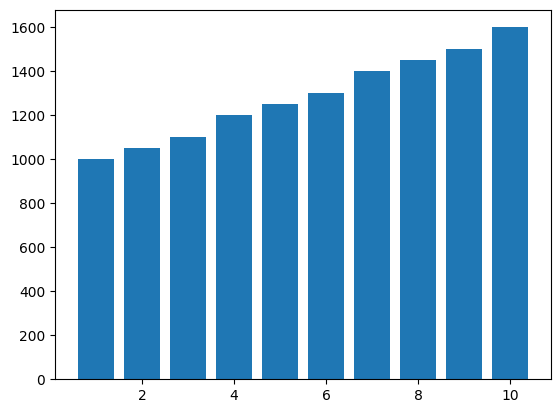

In [15]:
import pandas as pd
water_Tank=1800
data = {
    'Day': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Water_Consumption': [1000, 1050, 1100, 1200, 1250,
                          1300, 1400, 1450, 1500, 1600]
}

df = pd.DataFrame(data)

print("Dataset:")
print(df)
daily_inc=[]
for i in range(len(df['Water_Consumption'])-1):
    daily_inc.append(abs(df['Water_Consumption'][i+1]-df['Water_Consumption'][i]))
print(f"Daily Water Consumption: {daily_inc}")

avg=sum(daily_inc)/len(daily_inc)
print(f"Average Water Consumption: {avg}")
if (df["Water_Consumption"][len(df["Water_Consumption"])-1]+avg)>water_Tank:
    print("not sufficient")
else:
    print("Yes we can use water")
import matplotlib.pyplot as plt
plt.bar(df["Day"],df["Water_Consumption"])
